# 4. Where audio does win, and what breadth does to the gap

Notebook 02 showed that a model reading the paperwork beats every audio model at naming the species.
Two responses to that are worth testing.

The first is that species is the wrong question. Ask one the paperwork cannot answer: given that this
is a sperm whale, does the clip contain a click?

The second is that 134 recordings is too small a design. The archive holds 54 species over 393
tapes, so the same question can be asked over eleven species and 228 recordings without downloading
anything.

Both are run below. Neither rescues the audio, and the one call type comparison that resolves runs
against it.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Works whether the kernel starts in the repository root or in experiments/.
sys.path.insert(0, str(Path.cwd() if (Path.cwd() / "src").is_dir() else Path.cwd().parent))

from src.config import load_config
from src.evaluate import families, tables
from src.results import config_directory

narrow = load_config("configs/base.yaml")
wide = load_config("configs/wide.yaml")
pd.set_option("display.width", 180)

print(f"{narrow.name}: {len(narrow.dataset.species)} species")
print(f"{wide.name}: {len(wide.dataset.species)} species")

base_10k: 3 species
wide_10k: 11 species


## 1. Posing a question the paperwork cannot answer

Each call type is posed inside a single species, so the collection code cannot give the answer away:
every clip in the task carries the same species. The control sees everything written down about the
recording, which is the same control the species task is measured against. That includes clip
duration, and it matters more here than anywhere: a note is written against a whole cut, so a longer
cut is more likely to carry any given call whatever the animal was doing.

A task has to clear 60 clips over 10 independent tapes to be fitted at all. Eight do.

In [2]:
call_types = [f for f in families.discover(narrow) if f.key != families.SPECIES_FAMILY]
print(f"{len(call_types)} call type tasks, each with its own control")

pd.DataFrame(
    [
        {
            "task": f.title,
            "models": ", ".join(f.members),
            "control": f.control,
            "classes": ", ".join(f.class_names),
        }
        for f in call_types
    ]
)

8 call type tasks, each with its own control


,task,models,control,classes
0,"KillerWhale, call",calltype_killerwhale_call,calltype_killerwhale_call_context,"absent, present"
1,"KillerWhale, chirp",calltype_killerwhale_chirp,calltype_killerwhale_chirp_context,"absent, present"
2,"KillerWhale, click",calltype_killerwhale_click,calltype_killerwhale_click_context,"absent, present"
3,"KillerWhale, squeal",calltype_killerwhale_squeal,calltype_killerwhale_squeal_context,"absent, present"
4,"KillerWhale, whistle",calltype_killerwhale_whistle,calltype_killerwhale_whistle_context,"absent, present"
5,"SpermWhale, click",calltype_spermwhale_click,calltype_spermwhale_click_context,"absent, present"
6,"SpermWhale, coda","calltype_spermwhale_coda, calltype_spermwhale_...",calltype_spermwhale_coda_context,"absent, present"
7,"SpermWhale, whistle",calltype_spermwhale_whistle,calltype_spermwhale_whistle_context,"absent, present"


## 2. What they score

Every margin is the audio model against its own control on identical folds. The trees ran ten
repeats, so fifty splits; one network ran a single split, so five.

In [3]:
rows = []
for family in call_types:
    for _, row in tables.family_margins(narrow, family).iterrows():
        rows.append({"task": family.title, **row})

margins = pd.DataFrame(rows).sort_values("margin", ascending=False)
margins["resolves"] = margins.p_value < 0.05
positive = (margins.margin > 0).sum()
print(f"{positive} of {len(margins)} margins are positive, {margins.resolves.sum()} resolves")
margins[
    ["task", "mean", "control", "margin", "low", "high", "p_value", "agreeing", "folds", "resolves"]
].round(4)

5 of 9 margins are positive, 1 resolves


,task,mean,control,margin,low,high,p_value,agreeing,folds,resolves
2,"KillerWhale, click",0.5970,0.4721,0.1249,-0.0398,0.2897,0.1339,37,50,False
4,"KillerWhale, whistle",0.5671,0.5225,0.0446,-0.0232,0.1124,0.1923,36,50,False
8,"SpermWhale, whistle",0.7129,0.6741,0.0387,-0.2676,0.3451,0.8004,26,50,False
0,"KillerWhale, call",0.6950,0.6618,0.0332,-0.2549,0.3213,0.8179,29,50,False
3,"KillerWhale, squeal",0.7690,0.7634,0.0056,-0.2236,0.2348,0.9611,29,50,False
5,"SpermWhale, click",0.7097,0.7397,-0.0301,-0.1463,0.0862,0.6057,25,50,False
1,"KillerWhale, chirp",0.5556,0.6071,-0.0515,-0.1466,0.0435,0.2813,32,50,False
6,"SpermWhale, coda",0.5770,0.7392,-0.1622,-0.3015,-0.0229,0.0234,46,50,True
7,"SpermWhale, coda",0.4533,0.6775,-0.2242,-0.6154,0.1669,0.1867,5,5,False


Five of nine margins point the right way and not one of them resolves. The comparison that does
resolve is sperm whale coda, where the control beats the audio by 0.162 with 46 of 50 folds agreeing.

This table read the opposite way until the control was corrected. It used to be denied the four
header fields, clip duration among them, and a Watkins note is written against a whole cut, so a
longer cut is more likely to carry any given call whatever the animal was doing. A control without
that field was clearing a lower bar than the model beside it.

In [4]:
resolved = margins[margins.resolves]
for _, row in resolved.iterrows():
    print(
        f"{row.task}: {row.margin:+.3f}, p = {row.p_value:.3f}, "
        f"{int(row.agreeing)} of {int(row.folds)} agreeing"
    )

widest = margins.iloc[0]
print()
print(f"largest margin: {widest.task} at {widest.margin:+.3f}, p = {widest.p_value:.2f}")
print(f"its interval spans {widest.low:+.3f} to {widest.high:+.3f}, which includes zero")

SpermWhale, coda: -0.162, p = 0.023, 46 of 50 agreeing

largest margin: KillerWhale, click at +0.125, p = 0.13
its interval spans -0.040 to +0.290, which includes zero


## 3. A finding that did not survive a better control

This has happened twice, and both retractions are recorded here rather than quietly dropped.

Sperm whale click sat at +0.141 with p = 0.044 while the control could not see the collection code.
Giving it that field moved the result to +0.125 at p = 0.084. Giving it the header fields as well
moved it to -0.030.

Killer whale whistle sat at +0.101 with p = 0.022 and was described in this repository as the one
place where listening won. With the corrected control it is +0.045 at p = 0.19.

Nothing about either audio model changed. A result that survives only while the control is missing a
column is not a result.

In [5]:
retracted = margins[
    margins.task.str.contains("click|whistle") & ~margins.task.str.contains("chirp")
]
retracted[["task", "mean", "control", "margin", "p_value", "agreeing", "folds"]].round(4)

,task,mean,control,margin,p_value,agreeing,folds
2,"KillerWhale, click",0.5970,0.4721,0.1249,0.1339,37,50
4,"KillerWhale, whistle",0.5671,0.5225,0.0446,0.1923,36,50
8,"SpermWhale, whistle",0.7129,0.6741,0.0387,0.8004,26,50
5,"SpermWhale, click",0.7097,0.7397,-0.0301,0.6057,25,50


## 4. The same question over eleven species

`configs/wide.yaml` differs from `configs/base.yaml` in the species list and nothing else. Same band,
same window, same seed, same fold rule. Eleven species carrying at least ten surviving tapes each.

The prediction written down before this ran was that every score would fall, because eleven classes
is harder than three, and that the interesting number is whether the gap narrows.

In [6]:
coverage = pd.read_csv(wide.paths.metadata / f"audit_coverage_{wide.name}.csv")
manifest = pd.read_parquet(wide.paths.metadata / f"manifest_{wide.name}.parquet")
recordings = manifest[manifest.keep].tape_id.nunique()

print(f"{coverage.kept_clips.sum()} clips over {recordings} recordings")
print(f"summing per species gives {coverage.kept_tapes.sum()}, because some tapes carry two")
coverage

7723 clips over 228 recordings
summing per species gives 238, because some tapes carry two


,species,clips,tapes,kept_clips,kept_tapes,kept_hours
0,Beluga_WhiteWhale,150,12,131,12,0.083201
1,HumpbackWhale,604,14,546,12,1.954924
2,KillerWhale,2647,65,2601,65,1.649322
3,Long_FinnedPilotWhale,1104,18,1067,18,0.854631
4,NorthernRightWhale,486,22,342,17,0.206564
5,Short_Finned(Pacific)PilotWhale,607,12,558,12,0.381441
6,SpermWhale,1379,63,1013,58,12.230502
7,SpinnerDolphin,524,12,443,12,0.652978
8,StripedDolphin,681,10,658,10,0.358903
9,Walrus,273,11,262,11,0.287265


## 5. The gap widened

Every score fell, as expected. The gap did not narrow, it roughly doubled, and it did so for the
pretrained encoder as much as for the hand engineered features.

Doubling the recordings did not rescue the audio. It made the paperwork look better, because there is
more paperwork to go on when there are more animals to tell apart.

In [7]:
comparison = []
for cfg in (narrow, wide):
    family = next(f for f in families.discover(cfg) if f.key == families.SPECIES_FAMILY)
    scores = tables.headline(tables.comparison(cfg, list(family.names))).set_index("model")["mean"]
    comparison.append(scores.rename(f"{len(cfg.dataset.species)} species"))

side_by_side = pd.concat(comparison, axis=1).loc[["logbook", "metadata", "xgboost", "probe"]]
side_by_side.round(3)

,3 species,11 species
model,,
logbook,0.997,0.920
metadata,0.868,0.575
xgboost,0.752,0.425
probe,0.739,0.437


In [8]:
for cfg in (narrow, wide):
    family = next(f for f in families.discover(cfg) if f.key == families.SPECIES_FAMILY)
    floor = families.strongest_floor(cfg, family)
    against = tables.family_margins(cfg, family, control=floor).set_index("model")
    for model in ("xgboost", "probe"):
        row = against.loc[model]
        print(
            f"{len(cfg.dataset.species):2d} species, {model:8s}: {row.margin:+.3f} "
            f"against {floor}, p = {row.p_value:.1e}, "
            f"{int(row.agreeing)} of {int(row.folds)}"
        )

 3 species, xgboost : -0.245 against logbook, p = 1.7e-08, 50 of 50
 3 species, probe   : -0.258 against logbook, p = 1.3e-06, 50 of 50
11 species, xgboost : -0.495 against logbook, p = 3.4e-16, 50 of 50
11 species, probe   : -0.483 against logbook, p = 3.8e-15, 50 of 50


## 6. Which field the paperwork leans on changes with breadth

On three species the collection code alone reaches 0.995 and the model splits mostly on sample rate
and latitude. On eleven, most of the gain moves to the noise conditions the recordist wrote down.

The confound is not one field. It is that a written description of the circumstances of a recording
identifies the animal, and which part of the description does the work depends on which animals are
being told apart.

In [9]:
for cfg in (narrow, wide):
    importance = pd.read_csv(config_directory(cfg) / "logbook" / "feature_importance.csv")
    share = importance.groupby("feature").gain.mean()
    share = (share / share.sum()).sort_values(ascending=False).head(4)
    print(f"{len(cfg.dataset.species)} species, what the logbook split on:")
    print(share.round(3).to_string())
    print()

3 species, what the logbook split on:
feature
native_sample_rate    0.457
latitude              0.350
collection_code       0.113
bytes_on_disk         0.049

11 species, what the logbook split on:
feature
cond_water_noise      0.417
cond_reverberation    0.164
longitude             0.087
cond_engine_noise     0.083



## 7. Where the paperwork stops working

The clearest test of whether the logbook is reading one field is what happens on the clips where
that field cannot answer. Test clips are split by what their collection code does to the species. A
code used by one species names it. A code used by several does not, and that is where an audio model
has to earn its result. A clip carrying no code at all is a third case.

Three species turns out to be the wrong place to run that test, and the table below says why.

In [10]:
ambiguity = pd.read_csv(config_directory(narrow) / "ambiguity_breakdown.csv")
ambiguity.pivot_table(index="model", columns="subset", values="macro_f1_mean").round(3)

subset,collection code not recorded,collection code unique to a species,native sample rate shared by species,native sample rate unique to a species
model,,,,
cnn,0.581,0.711,0.707,0.644
cnn_small,0.609,0.708,0.671,0.671
logbook,0.638,0.998,0.864,0.932
metadata,0.698,0.867,0.683,0.878
probe,0.514,0.746,0.708,0.679
xgboost,0.616,0.750,0.661,0.705


There is no shared column. Every collection code in these three species belongs to exactly one of
them, so the split has two sides and the second is the 359 clips carrying no code.

Read `classes_scored` before any score on that side. Those clips hold two of the three species, so a
three class average over them cannot pass two thirds however well a model does.

In [11]:
code = ambiguity[ambiguity.giveaway == "collection code"]
print(
    code[["model", "subset", "clips", "classes_scored", "classes_total", "folds"]]
    .drop_duplicates(subset=["subset"])
    .to_string(index=False)
)

scores = code.set_index(["model", "subset"]).macro_f1_mean
print()
for model in ("logbook", "metadata", "xgboost"):
    named = scores[(model, "collection code unique to a species")]
    missing = scores[(model, "collection code not recorded")]
    print(f"{model:9s} {named:.3f} where the code names it, {missing:.3f} where there is none")

  model                              subset  clips  classes_scored  classes_total  folds
xgboost        collection code not recorded    359               2              3     43
xgboost collection code unique to a species   3801               3              3     50

logbook   0.998 where the code names it, 0.638 where there is none
metadata  0.867 where the code names it, 0.698 where there is none
xgboost   0.750 where the code names it, 0.616 where there is none


The logbook falls furthest, and every model falls. The control that never sees a code at all
finishes highest of the three, which is what rules out reading the fall as the collection code being
taken away. Those 359 clips are simply harder, and they are eight recordings.

Eleven species is where the question can actually be asked, because there a code is shared.

In [12]:
broad = pd.read_csv(config_directory(wide) / "ambiguity_breakdown.csv")
broad_code = broad[broad.giveaway == "collection code"]
shape = ["model", "subset", "clips", "classes_scored", "classes_total"]
print(broad_code[shape].to_string(index=False))

shared = broad_code[broad_code.subset == "collection code shared by species"].set_index("model")
print()
print(f"on the {int(shared.clips.iloc[0])} clips whose code several species use:")
for model in ("logbook", "metadata", "xgboost"):
    print(f"  {model:9s} {shared.macro_f1_mean.loc[model]:.3f}")

   model                              subset  clips  classes_scored  classes_total
 xgboost        collection code not recorded    361               3             11
 xgboost   collection code shared by species   2581               4             11
 xgboost collection code unique to a species   4781              10             11
 logbook        collection code not recorded    361               3             11
 logbook   collection code shared by species   2581               4             11
 logbook collection code unique to a species   4781              10             11
   probe        collection code not recorded    361               3             11
   probe   collection code shared by species   2581               4             11
   probe collection code unique to a species   4781              10             11
metadata        collection code not recorded    361               3             11
metadata   collection code shared by species   2581               4             11
meta

The logbook still more than doubles the audio model where the code is genuinely ambiguous. Whatever
the paperwork carries, it is not one field.

native sample rate


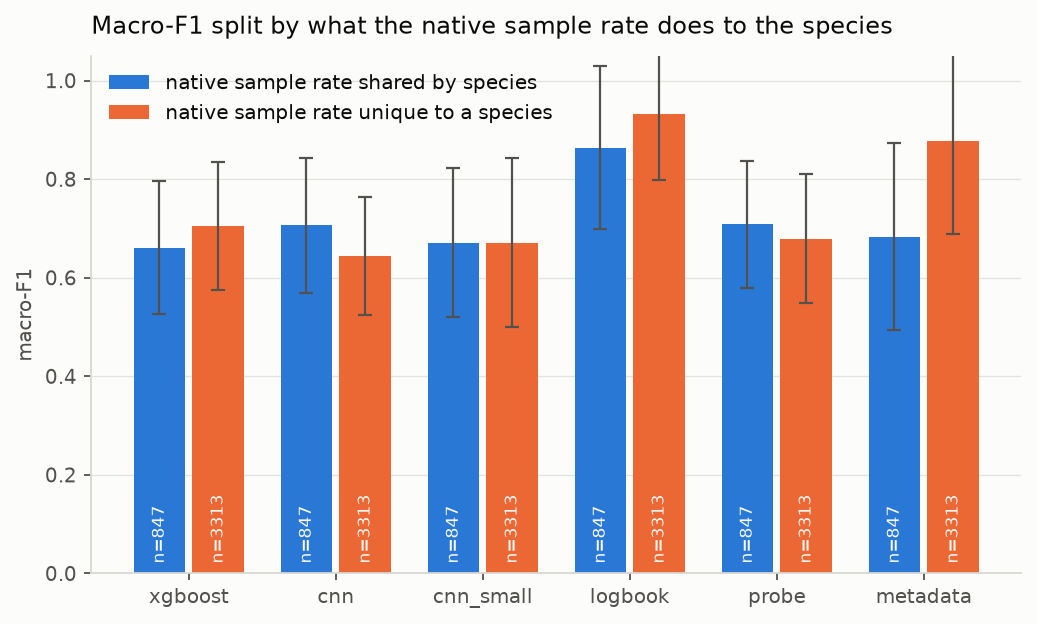

collection code


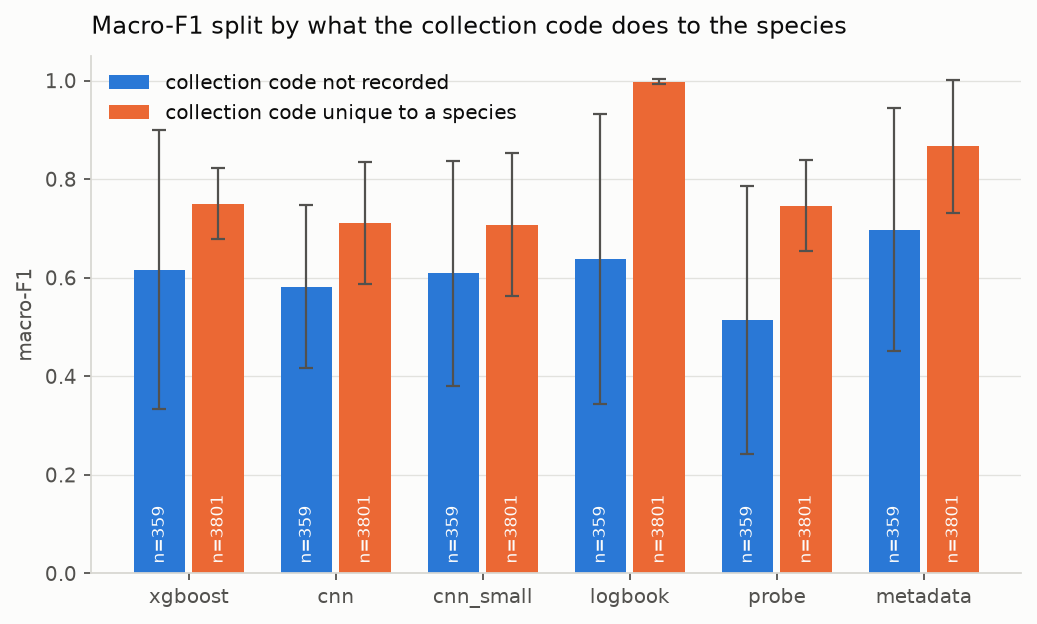

In [13]:
for field in ambiguity.giveaway.unique():
    stem = field.replace(" ", "_")
    path = config_directory(narrow) / f"ambiguity_{stem}.png"
    if path.exists():
        print(field)
        display(Image(filename=str(path)))

## What this notebook does not settle

The call type tasks rest on between ten and forty four recordings each. Eight positive margins out of
nine is suggestive and one resolved comparison is thin evidence, and neither becomes stronger by
being restated.

Eleven species bought more recordings and more classes at the same time, and the two pull against
each other. Some classes land a single test tape in some folds, so those per fold scores rest on one
recording. Eight of the 228 recordings carry two of the eleven species, so the classes sharing a tape
are not scored on independent evidence: long finned pilot whale shares six of its eighteen tapes with
sperm whale.

The networks were not run on the wide set, so nothing here says whether a learned representation
behaves differently at eleven classes.